# 에너지 차익거래 및 피크 저감을 위한 배터리 저장장치 급전 최적화

## 요약

계통 연계된 상업용 사업장이 계량된 전기 부하와 함께 2 MW / 8 MWh 리튬이온 배터리를 운용합니다. 이 사업장은 두 가지 방식으로 요금이 부과됩니다: 시간별 하루 전 **에너지 가격**($/MWh)과, 단일 최고 계통 수전 구간에 부과되는 월간 **수요요금**($/MW). 자산 관리자는 시간별로, 언제 배터리를 충전할지(저렴한 에너지를 사고 계통 수전을 높임)와 언제 방전할지(비싼 에너지를 상쇄하고 계통 수전을 낮춤)를 결정해야 합니다. 두 가치 흐름이 경쟁합니다: **에너지 차익거래**(야간에 싸게 사서 저녁 피크에 방전)와 **피크 저감**(청구되는 계통 최댓값 상한 억제). 충전은 공짜가 아닙니다 — 왕복 효율로 인해 저장 에너지의 약 10%가 손실됩니다 — 따라서 이 스케줄은 휴리스틱이 아니라 진정한 최적화입니다.

이 노트북은 의사결정을 처음부터 끝까지 구축합니다. 먼저 현실적인 24시간 하루 전 가격 곡선(오전·저녁 피크에 야간 저점)과 상관된 사업장 부하 프로파일을 합성한 다음, 둘 다 **PROC MEANS**와 강건한 **PROC UNIVARIATE** 2.5/97.5 백분위 가격 구간으로 프로파일링합니다. 핵심은 **PROC OPTMODEL**의 선형계획법입니다: 시간별 충전, 방전, 충전상태에 대한 결정변수와 청구 피크 변수, 그리고 누적 충전상태 균형(충전/방전 효율 분리), 전력·용량 한계, 피크 정의 제약을 따릅니다. 목적함수는 수요요금을 차감한 차익거래 마진을 최대화합니다. 그다음 **PROC SQL**이 기준 대비 최적화 비용을 정량화하고, 세 개의 **PROC SGPLOT** 패널이 가격 대비 충방전 스케줄, 충전상태 궤적, 평탄화된 계통 수전 프로파일을 시각화합니다.

**합성된 하루에 대한 결과:** 최적화기는 가장 저렴한 야간 시간대에 배터리를 채우고, 오전과 저녁 가격 피크 모두에 방전하며, 한낮 가격 골에서 재충전하고 — 결정적으로 — 새로운 계통 피크를 만들지 않도록 충전 전력을 억제합니다. 일일 에너지 비용은 **\$2,903.78에서 \$2,528.43으로** 하락합니다 — **차익거래 절감액 \$375.34(12.9%)** — 동시에 청구되는 계통 최댓값은 **3.59 MW에서 3.43 MW로**(약 **0.16 MW**) 떨어지며, 가정된 일할 수요요금에서 추가로 **\$18.98**의 가치가 있습니다. 동일한 모델은 인덱스 집합과 제약을 확장하기만 하면 더 긴 시간 지평, 다중 가격 시나리오, 열화 인식 사이클링으로 확장됩니다.

## 데이터 출처

모든 데이터는 **합성**이며, 재현성을 위해 첫 코드 셀에서 `CALL STREAMINIT(20260605)`로 인라인 생성됩니다. 외부 파일이나 네트워크 접근이 없습니다. 하나의 운영일을 나타내는 24개 시간별 행을 가진 단일 데이터셋 `price_load`입니다.

| 변수 | 유형 | 단위 | 설명 |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | 운영일의 시간(시간 지평 인덱스) |
| `price` | num | $/MWh | 하루 전 에너지 가격: 야간 저점, 오전 + 저녁 피크, 가우시안 잡음 포함($5에서 하한) |
| `load` | num | MW | 일일 활동과 상관된 사업장 전력 수요(0.3 MW에서 하한) |
| `day_type` | char | — | 요금 창 플래그: `PeakTOU`(17–21시) 대 `OffPeak`, 피크/오프피크 가격 스프레드 요약에 사용 |

배터리 파라미터는 PROC OPTMODEL 내부의 고정 모델 상수입니다: 사용 가능 용량 8 MWh, 최대 충방전 전력 2 MW, 충전 효율 0.95 및 방전 효율 0.95(~90% 왕복), 시작 충전상태 0 MWh, 그리고 그날 청구되는 계통 피크에 적용되는 \$120/MW 수요요금(월간 수요요금의 일할 배분 몫).

# 배터리 저장장치 급전 최적화
## 계통 연계 사업장을 위한 에너지 차익거래와 피크 저감

한 상업용 사업장이 계량기 뒤에서 **2 MW / 8 MWh 배터리**를 운용합니다. 전기 요금은 두 부분으로 구성됩니다: 시간별 **에너지 가격**($/MWh)과, 단일 최고 계통 수전 구간에 부과되는 월간 **수요요금**($/MW). 운영자는 두 가치 흐름을 동시에 포착하는 시간별 충방전 스케줄을 원합니다:

- **차익거래** — 저렴한 야간 에너지를 저장하고, 비싼 피크 시간에 방출합니다.
- **피크 저감** — 수요 급증 시 방전하여 청구되는 계통 최댓값을 낮춥니다.

왕복 효율이 저장 에너지의 ~10%를 잃기 때문에, 이 상충은 사소하지 않으며 진정한 최적화를 정당화합니다. 우리는 이를 **PROC OPTMODEL**의 선형계획법으로 정식화한 다음, 결과를 정량화하고 시각화합니다.

> 아래 모든 데이터는 합성이며 인라인 생성됩니다 — 이 노트북은 완전히 자기 완결적이며 몇 초 안에 실행됩니다.

## 1. 합성 하루 전 가격 및 부하 프로파일 생성

우리는 하나의 운영일(24개 시간별 행)을 구축합니다. 가격 곡선에는 야간 저점과 오전 + 저녁 피크가 있고, 사업장 부하는 일일 활동과 상관됩니다. 고정 시드는 실행을 재현 가능하게 유지합니다. 나중에 피크/오프피크 스프레드를 요약할 수 있도록 법정 사용시간대 피크 창도 표시합니다.

In [1]:
데이터 price_load;
    호출 streaminit(20260605);
    길이 day_type $18;
    반복 hour = 0 까지 23;
        /* 일중 전력 가격($/MWh): 오전·저녁 피크 */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        만약 price < 5 이면 price = 5;

        /* 시설 부하(MW): 심야 저점, 저녁 상승 */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        만약 LOAD < 0.3 이면 LOAD = 0.3;

        만약 hour >= 17 그리고 hour <= 21 이면 day_type = '피크 시간대';
        아니면 day_type = '오프피크';
        출력;
    종료;
    제거 BASE;
실행;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. 가격 및 부하 분포 프로파일링

최적화 전에 입력값을 점검합니다. 가장 저렴한 시간과 가장 비싼 시간 사이의 스프레드가 차익거래가 수익화하는 대상이며, 최대 부하가 피크 저감 기회를 고정합니다.

In [2]:
처리 평균 데이터=price_load n mean std MIN MAX maxdec=2;
    변수 price LOAD;
    라벨 price="전력 가격($/MWh)" LOAD="시설 부하(MW)";
    제목 '전력 가격과 시설 부하의 요약 통계';
실행;

                                                  전력 가격과 시설 부하의 요약 통계                                                   

                                                  The MEANS Procedure

 Variable  Label                       N        Mean     Std Dev     Minimum     Maximum
 ---------------------------------------------------------------------------------------
 price     전력 가격($/MWh)               24       46.29       15.81       18.57       79.27
 LOAD      시설 부하(MW)                  24        2.47        0.48        1.71        3.59
 ---------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. 피크 대 오프피크 가격 스프레드

사용시간대 플래그로 그룹화하면 온피크 시간이 오프피크 기준보다 얼마나 더 풍부한지 드러납니다 — 배터리가 활용하는 구조적 신호입니다.

In [3]:
처리 평균 데이터=price_load mean MIN MAX maxdec=2;
    분류 day_type;
    변수 price;
    라벨 day_type="시간대 구분" price="전력 가격($/MWh)";
    제목 '시간대 구분별 전력 가격';
실행;

                                                     시간대 구분별 전력 가격                                                      

                                                  The MEANS Procedure

                                    Analysis Variable : price 전력 가격($/MWh)

                                                    N
                              시간대 구분              Obs       Mean      Minimum      Maximum
                              ------------------------------------------------------------
                              오프피크                 19      40.46        18.57        54.89
                              피크 시간대                5      68.45        54.88        79.27
                              ------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. 강건한 가격 구간 (2.5 / 97.5 백분위수)

우리는 2.5 / 97.5 백분위 구간으로 가격 꼬리를 특성화합니다. `PCTLPTS=`를 사용한 **PROC UNIVARIATE**는 임의의 백분위수를 깔끔하게 계산하며, 이는 분수 백분위수에 대한 올바른 도구입니다.

In [4]:
처리 단변량 데이터=price_load NOPRINT;
    변수 price;
    출력 out=price_band pctlpts=2.5 97.5 pctlpre=p_;
실행;

처리 인쇄 데이터=price_band noobs;
    제목 '전력 가격의 2.5~97.5 백분위 구간';
실행;

                                                 전력 가격의 2.5~97.5 백분위 구간                                                 

P_2_5  P_97_5
18.57   79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. 급전 최적화 (선형계획법)

우리는 시간별 가격과 부하를 PROC OPTMODEL에 읽어들이고 다음을 선언합니다:

- `chg[h]`, `dis[h]` — 시간별 충전 / 방전 전력(MW), 2 MW 인버터 정격으로 제한.
- `soc[h]` — 충전상태(MWh), 8 MWh 사용 가능 용량으로 제한.
- `peak` — 청구되는 계통 최댓값(MW).

**제약.** `soc_balance`는 충전/방전 효율을 분리하여 각 시간을 통해 순 에너지를 누적합니다(시간별 점화식의 누적합 형태). `peak_def`는 `peak`이 매 시간의 순 계통 수전을 지배하도록 강제하므로, 이를 최소화하면 수요요금이 저감됩니다.

**목적함수.** 차익거래 마진을 최대화합니다 — 하루에 걸쳐 합산한 `price × (discharge − charge)` — 에서 청구 피크에 대한 수요요금을 뺍니다. 우리는 이를 연속 LP로 풉니다.

In [5]:
처리 optmodel;
    설정 HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ 데이터 price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* 배터리: 사용 가능 8 MWh, 출력 2 MW, 왕복 효율 ~90% */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* 이 날 청구되는 계통 피크에 부과되는 수요요금($/MW).
       상업용 수요요금은 월 단위이며, 120은 월 요금을 하루로
       상각했을 때 오늘의 계통 최댓값을 깎는 한계 가치이다.
       충분히 커서 최적화기가 더 높은 새 피크를 만들기보다
       충전 출력을 억제하도록 만든다. */
    num demand_chg = 120;

    /* 의사결정 변수(충전/방전 MW, 충전 상태 MWh) */
    변수 chg{HOURS}  >= 0 <= p_max;
    변수 dis{HOURS}  >= 0 <= p_max;
    변수 soc{HOURS}  >= 0 <= capacity;
    변수 peak        >= 0;   /* 수요요금용 청구 계통 피크(MW) */

    /* 배터리 동작 후 순 계통 수입(MW) */
    impvar grid_mw{h IN HOURS} = LOAD[h] + chg[h] - dis[h];

    /* 누적 충전 상태: 시각 h까지 유입 에너지에서 유출 에너지를 뺀 값,
       충·방전 효율 적용. 시간별 점화식과 동치이나 이전 시각들에
       대한 running sum으로 표현. */
    con soc_balance{h IN HOURS}:
        soc[h] = soc0
                 + sum{k IN HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* 피크 셰이빙: 청구 피크는 하루 중 계통 수입의 최댓값 */
    con peak_def{h IN HOURS}: peak >= grid_mw[h];

    /* 수요 피크 요금을 뺀 에너지 차익거래 마진 최대화 */
    MAX net_value =
        sum{h IN HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREATE 데이터 dispatch FROM [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;

                                                 전력 가격의 2.5~97.5 백분위 구간                                                 


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. 최적 시간별 스케줄

풀린 표는 저렴한 야간 및 한낮 시간에 걸쳐 분산된 충전 — 새로운 계통 피크를 절대 세우지 않도록 대략 1.0–1.7 MW로 조절됨 — 오전과 저녁 가격 피크에 집중된 방전, 그리고 8 MWh 상한 안에서 합리적인 충전-방출 사이클을 그리는 충전상태를 보여줍니다. `grid_mw` 열은 매 충전 시간에 걸쳐 평평한 ~3.43 MW 천장을 유지하는데, 이는 구속력 있는 피크 제약의 특징입니다.

In [6]:
처리 인쇄 데이터=dispatch noobs 라벨;
    변수 hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    라벨 hour="시각(시)" price="전력 가격($/MWh)" LOAD="시설 부하(MW)"
          charge_mw="충전 전력(MW)" discharge_mw="방전 전력(MW)"
          soc_mwh="충전량(MWh)" grid_mw="계통 수입(MW)";
    제목 '최적 디스패치 일정(시간별)';
실행;

                                                    최적 디스패치 일정(시간별)                                                     

      시각(시)          전력 가격($/MWh)          시설 부하(MW)          충전 전력(MW)          방전 전력(MW)        충전량(MWh)          계통 수입(MW)
          0                 29.73               1.99          1.4418421                  0         1.36975          3.4318421
          1                 28.03               2.16          1.2718421                  0           2.578          3.4318421
          2                 21.87                  2          1.4318421                  0         3.93825          3.4318421
          3                 18.57               1.71          1.7218421                  0           5.574          3.4318421
          4                 27.62               2.13          1.3018421                  0         6.81075          3.4318421
          5                 36.12               2.18          1.2518421                  0               8          3.4318


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. 핵심 KPI: 기준 대 최적화

우리는 아무것도 하지 않는 기준(매 시간 원시 부하에 대해 가격을 지불)과 최적화된 계통 위치를 비교하고, 차익거래 절감액, 청구 피크의 감소, 그리고 수요요금에서 그 감소의 금액 가치 — 비즈니스 사례를 이끄는 두 지렛대 — 를 보고합니다.

In [7]:
처리 SQL;
    CREATE TABLE kpi AS
    선택
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    FROM dispatch;
QUIT;

처리 인쇄 데이터=kpi noobs 라벨;
    라벨 base_energy_cost="기준 에너지 비용" opt_energy_cost="최적화 후 에너지 비용"
          arbitrage_savings="차익거래 절감" base_peak_mw="기준 피크(MW)"
          opt_peak_mw="최적화 후 피크(MW)" peak_reduction_mw="피크 감소(MW)"
          demand_charge_savings="수요요금 절감";
    제목 'KPI 요약: 차익거래와 피크 셰이빙 효과';
실행;

                                                    최적 디스패치 일정(시간별)                                                     

                                                KPI 요약: 차익거래와 피크 셰이빙 효과                                                 

              기준 에너지 비용                    최적화 후 에너지 비용              차익거래 절감          기준 피크(MW)              최적화 후 피크(MW)          피크 감소(MW)              수요요금 절감
              2903.7774                 2528.4335145526       375.3438854474               3.59                 3.4318421          0.1581579            18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. 가격 대비 충전 / 방전 스케줄

충전(파란색 니들)과 방전(마커가 있는 빨간색 선)은 왼쪽 메가와트 축을 공유하고, 하루 전 가격(녹색 점선)은 오른쪽에서 읽습니다. 충전은 저렴한 야간 및 한낮 시간에 모이는 반면, 방전은 오전과 저녁 가격 피크로 발사됩니다 — 시각 자료는 최적화기가 싸게 사서 비싸게 팔고 있음을 확인합니다.

                                                KPI 요약: 차익거래와 피크 셰이빙 효과                                                 




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


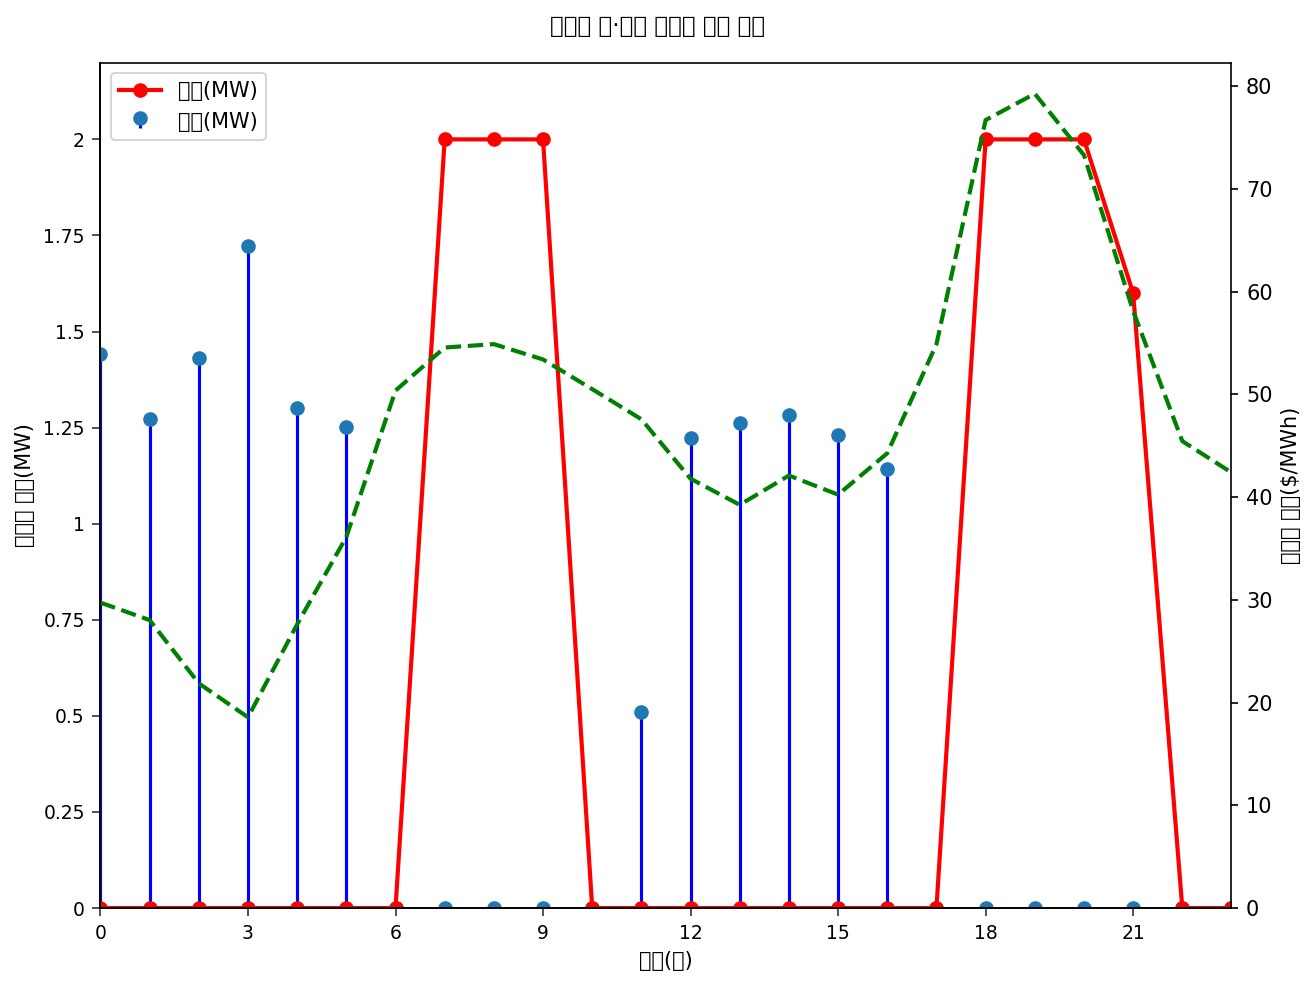

In [8]:
처리 SGPLOT 데이터=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="충전(MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="방전(MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="가격($/MWh)";
    XAXIS 라벨="시각(시)" VALUES=(0 까지 23 기준 3);
    YAXIS 라벨="배터리 출력(MW)" MIN=0 MAX=2.2;
    y2axis 라벨="에너지 가격($/MWh)" MIN=0;
    제목 '배터리 충·방전 일정과 전력 가격';
실행;

## 9. 충전상태 궤적

저장 에너지는 야간에 배터리가 채워지면서 상승하고, 각 방전 창을 통해 감소하며, 8 MWh 사용 가능 용량 천장(점선 참조)을 절대 넘지 않습니다.

                                                KPI 요약: 차익거래와 피크 셰이빙 효과                                                 




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


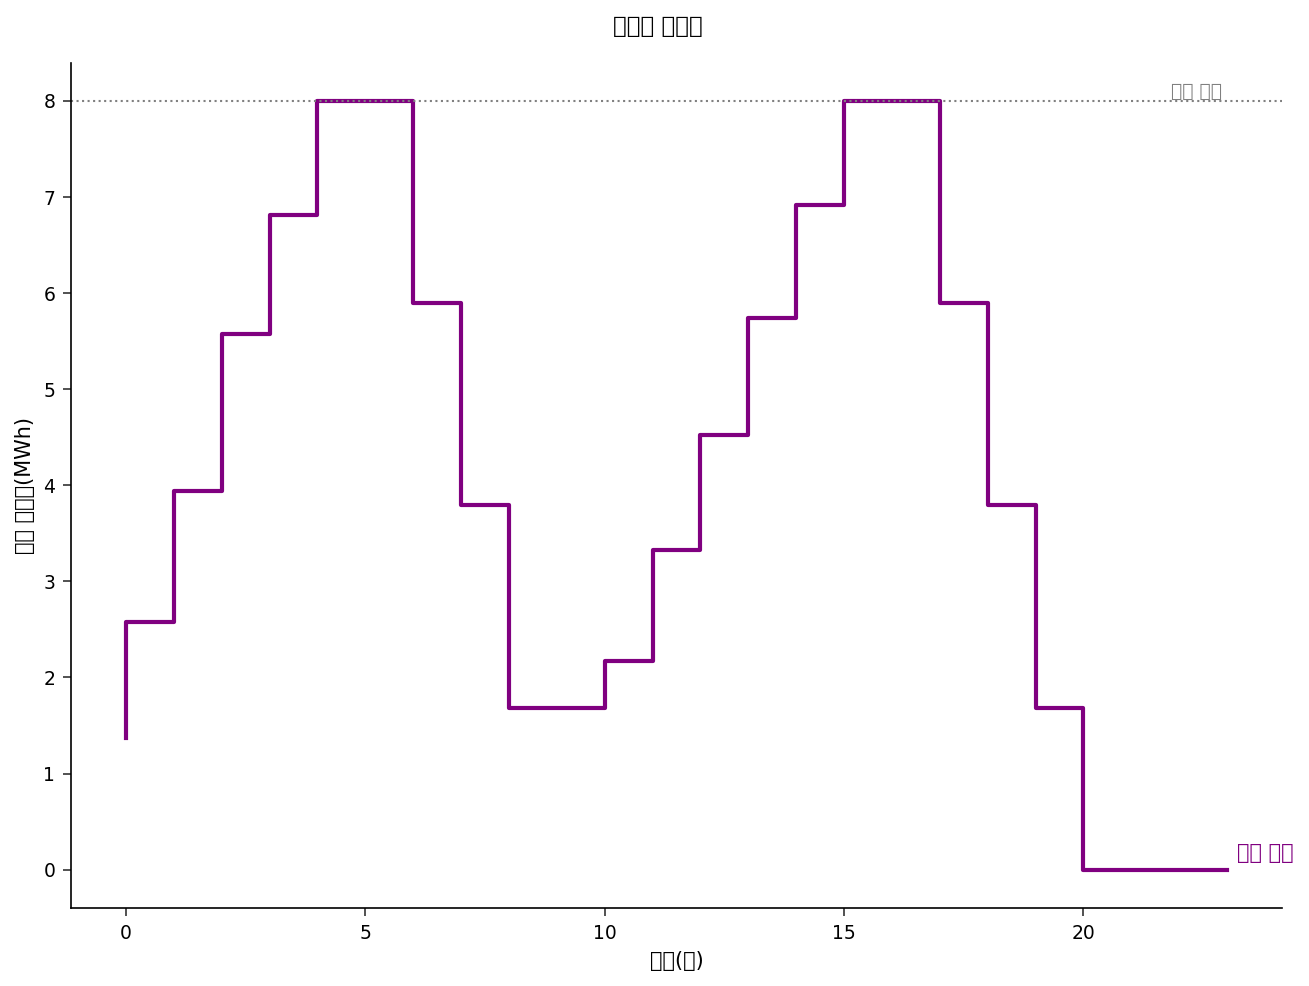

In [9]:
처리 SGPLOT 데이터=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="충전 상태";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        라벨="가용 용량";
    XAXIS 라벨="시각(시)";
    YAXIS 라벨="저장 에너지(MWh)";
    제목 '시간별 충전량';
실행;

## 10. 계통 수전: 급전 전 대 후

주황색 선(배터리가 있는 계통 수전)은 저녁 램프(18–21시)를 통해 점선 기준 부하보다 훨씬 아래로 떨어집니다 — 수요요금을 낮추는 피크 저감 효과입니다. 야간 및 한낮 충전 창 동안에는 상승하지만, 최적화기는 이를 원래 3.59 MW 부하 피크보다 *아래*에 머무는 평평한 ~3.43 MW 천장으로 억제하므로, 충전은 새로운 청구 최댓값을 세우지 않고 저렴한 에너지를 삽니다.

                                                KPI 요약: 차익거래와 피크 셰이빙 효과                                                 




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


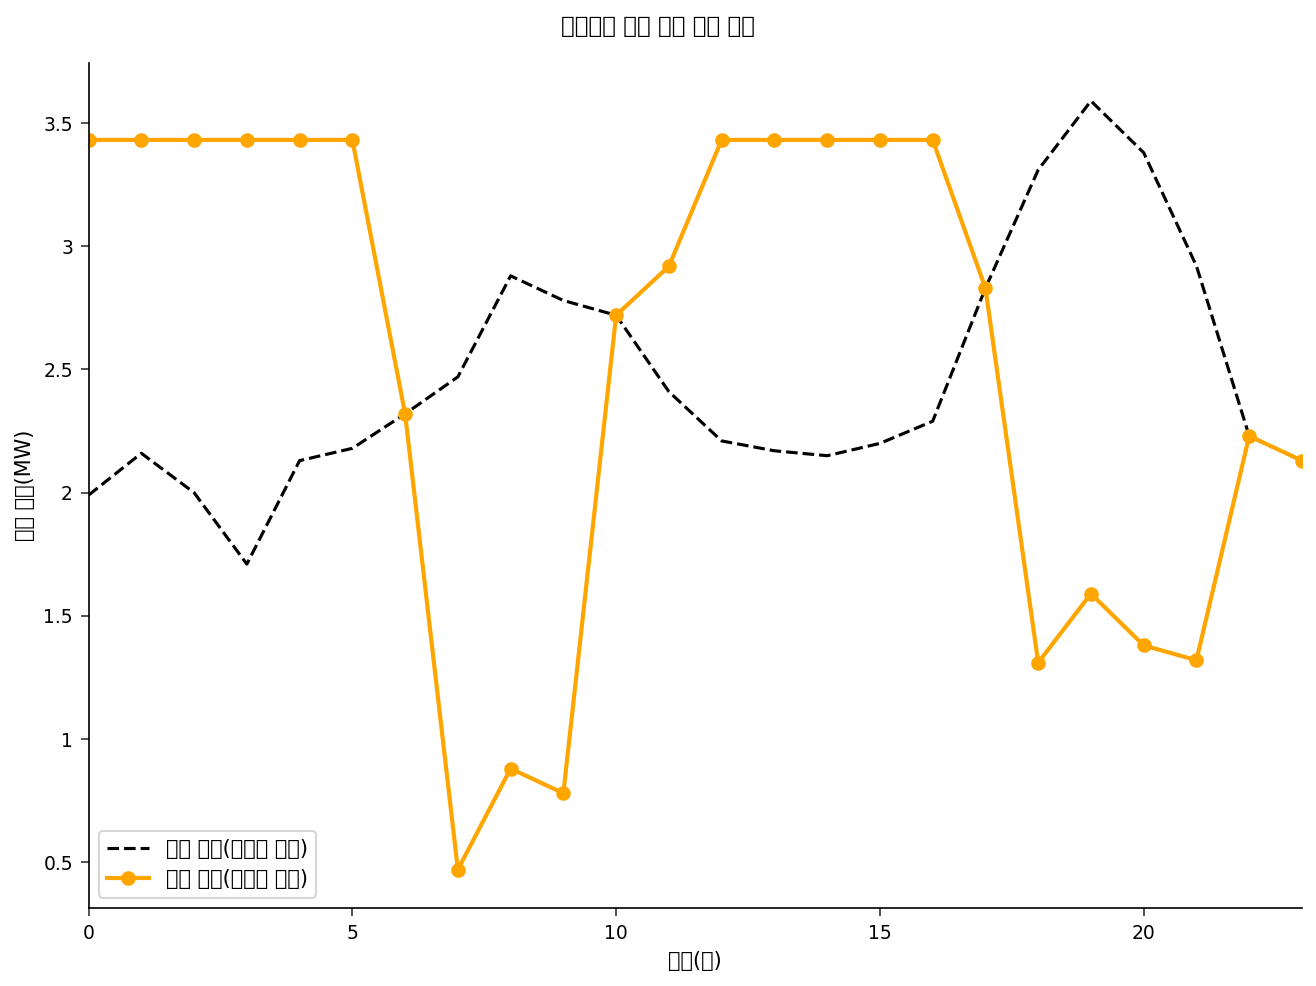

In [10]:
처리 SGPLOT 데이터=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="시설 부하(배터리 없음)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="계통 수입(배터리 있음)";
    XAXIS 라벨="시각(시)";
    YAXIS 라벨="계통 수입(MW)";
    제목 '배터리에 의한 계통 피크 감소';
실행;

## 해석 및 다음 단계

**모델이 결정한 것.** 왕복 효율이 매 사이클에 과세하는데도, 최적화기는 여전히 명확한 가치를 찾았습니다: 가장 저렴한 야간 시간에 배터리를 채우고, 오전 가격 피크(7–9시)에 방전하며, 한낮 가격 골(11–16시)을 통해 재충전하고, 가장 풍부한 저녁 피크(18–21시)에 다시 방전했습니다. 시사하듯, 야간 충전 동안 전체 2 MW 정격이 아니라 1.0–1.7 MW로만 충전했습니다 — 추가된 계통 수전이 그날의 부하 피크를 넘어서지 않도록 전력을 억제한 것입니다. 충전상태는 항상 8 MWh 용량과 2 MW 전력 한계를 모두 존중했습니다.

**비즈니스 사례.** 일일 에너지 비용은 **\$2,903.78에서 \$2,528.43으로** 하락했고 — **차익거래 절감액 \$375.34(12.9%)** — 청구되는 계통 최댓값은 **3.59 MW에서 3.43 MW로**(약 **0.16 MW**) 떨어져 수요요금 항목에서 추가로 **\$18.98**을 절감했습니다. 운영일 전반에 걸쳐 연간화하고 반복되는 수요요금 감소를 더하면, 이것이 저장장치 투자를 뒷받침하는 종류의 마진입니다.

**LP가 올바른 도구인 이유.** 휴리스틱("중앙값 가격 아래에서 충전, 위에서 방전")은 효율 손실, 시간 간 용량 결합, 그리고 수요요금이 단일 구간에 의존한다는 사실을 무시합니다 — 그것들은 야간에 전력을 최대로 충전하여 청구 피크를 *높이고* 피크 저감 가치를 파괴할 것입니다. PROC OPTMODEL은 이 모든 것을 하나의 선언적 모델에 담아 증명 가능하게 최적인 스케줄을 반환하며, 여기서는 피크를 보호하기 위해 충전율을 의도적으로 조절합니다.

**모델 확장.**

- **더 긴 시간 지평 / 다일** — `HOURS` 인덱스 집합을 넓히고, 일간 사이클링 한계를 추가합니다.
- **가격 불확실성** — 여러 가격 시나리오에 걸쳐 LP를 풀고 첫 시간 결정을 평균합니다(롤링 확률적 정책).
- **배터리 열화** — 처리량 페널티 항 또는 누적 사이클 제약을 추가하여 차익거래와 자산 수명을 상충시킵니다.
- **주파수 응답 / 용량 시장** — 예약 여유 제약을 도입하여 배터리가 차익거래 위에 부가 서비스 수익을 쌓을 수 있게 합니다.

이 모든 것은 동일한 OPTMODEL 블록에 대한 점진적 편집입니다 — 여기서 확립된 구조가 변경 없이 이어집니다.